In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import nltk
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\praph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\praph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\praph\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\praph\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
df=pd.read_csv(r'D:\ProjectExhibition1\ProjectExb\Corona_Wave1.csv')

In [3]:

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean text
def clean_text(text):
    try:
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        # Remove special characters and numbers
        text = re.sub(r'[^A-Za-z\s]', '', text)
        # Lowercase the text
        text = text.lower()
        # Tokenize the text
        tokens = word_tokenize(text)
        # Remove stop words
        tokens = [word for word in tokens if word not in stopwords.words('english')]
        # Lemmatize the tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        # Join the tokens back into a single string
        cleaned_text = ' '.join(tokens)
        return cleaned_text
    except Exception as e:
        print(f"Error processing text: {text}\n{e}")
        return ''


# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)


In [5]:
print(df[['cleaned_text']].head())

                                        cleaned_text
0  one want study communist propaganda china viru...
1  chance create covid relief fund india many hap...
2  fairness probably cant pronounce corona virus ...
3   bread left supermarket lot eat bread corona came
4  joke mean itmaybe start asking mothercousins a...


In [6]:
!pip install transformers torch


  Using cached torch-2.5.1-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached filelock-3.16.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached PyYAML-6.0.2-cp312-cp312-win_amd64.whl.metadata (2.1 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached safetensors-0.4.5-cp312-none-win_amd64.whl.metadata (3.9 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached fsspec-2024.10.0-py3-none-any.whl.metadata (11 kB)
  Using cached setuptools-75.6.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached MarkupSafe-3.0.2-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached charset_normalizer-3.4.0-cp312-cp312-win_amd64.whl.metadata (34 kB)
  Using cached idna-3.10-py3-

In [8]:
from transformers import pipeline
from tqdm import tqdm  # Import tqdm for the progress bar

# Load the pre-trained emotion analysis model
emotion_classifier = pipeline('text-classification', model='j-hartmann/emotion-english-distilroberta-base')

# Define a function to classify emotions in the text
def classify_emotion(text):
    result = emotion_classifier(text)
    return result[0]['label']  # Get the emotion label

# Use tqdm to show the progress of text classification
tqdm.pandas()  # Enable tqdm for pandas progress_apply

# Apply the emotion classification function to the cleaned text with progress bar
df['emotion'] = df['cleaned_text'].progress_apply(classify_emotion)

# Display the first few rows to see the emotions
print(df[['cleaned_text', 'emotion']].head())


Device set to use cpu
100%|██████████| 20100/20100 [13:38<00:00, 24.54it/s]

                                        cleaned_text  emotion
0  one want study communist propaganda china viru...  neutral
1  chance create covid relief fund india many hap...      joy
2  fairness probably cant pronounce corona virus ...  neutral
3   bread left supermarket lot eat bread corona came  neutral
4  joke mean itmaybe start asking mothercousins a...  neutral


C:\Users\praph\AppData\Local\Temp\ipykernel_13460\879817388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')


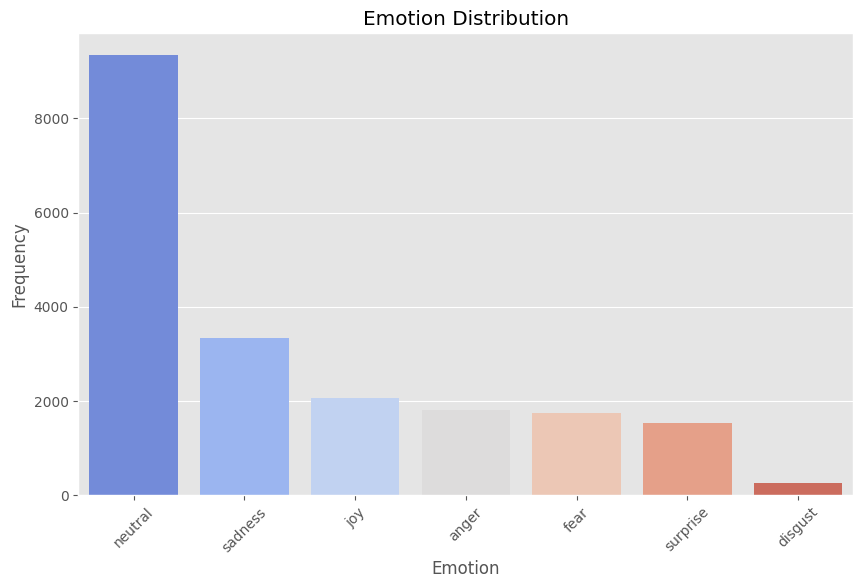

In [9]:
# Count the occurrences of each emotion
emotion_counts = df['emotion'].value_counts()

# Plot the distribution of emotions
plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


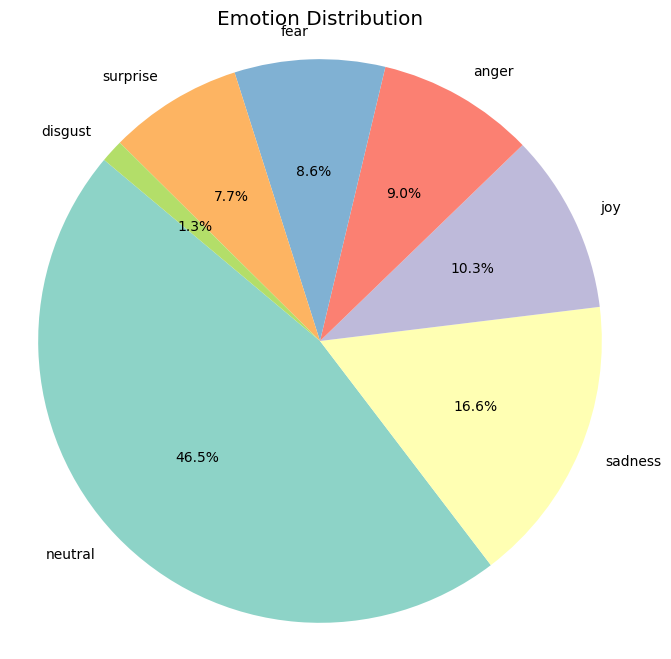

In [10]:
# Count the occurrences of each emotion
emotion_counts = df['emotion'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(emotion_counts)))

# Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.axis('equal')
plt.title('Emotion Distribution')

# Show the plot
plt.show()

C:\Users\praph\AppData\Local\Temp\ipykernel_13460\1043761656.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')


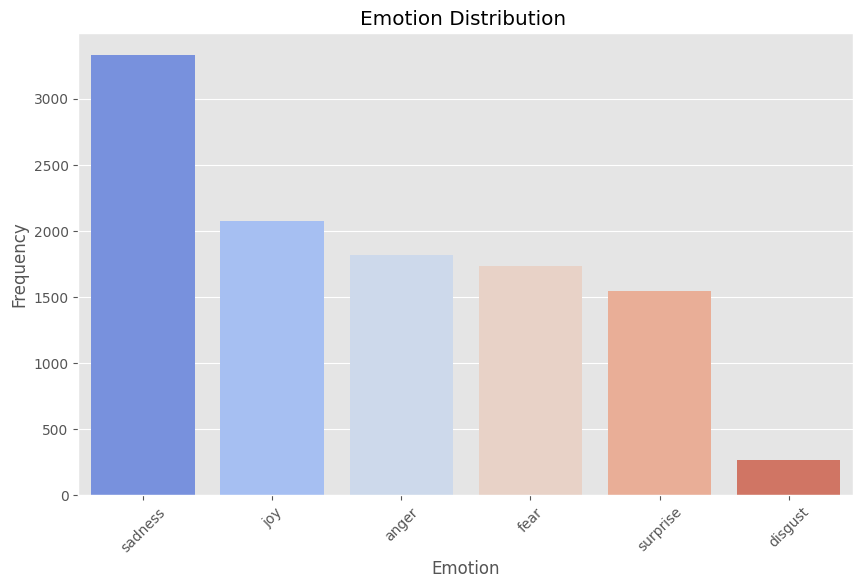

In [13]:
# Filter out 'neutral' emotion
filtered_df = df[df['emotion'] != 'neutral']

# Count the occurrences of each emotion (excluding neutral)
emotion_counts = filtered_df['emotion'].value_counts()

# Plot the distribution of emotions
plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='coolwarm')
plt.title('Emotion Distribution ')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


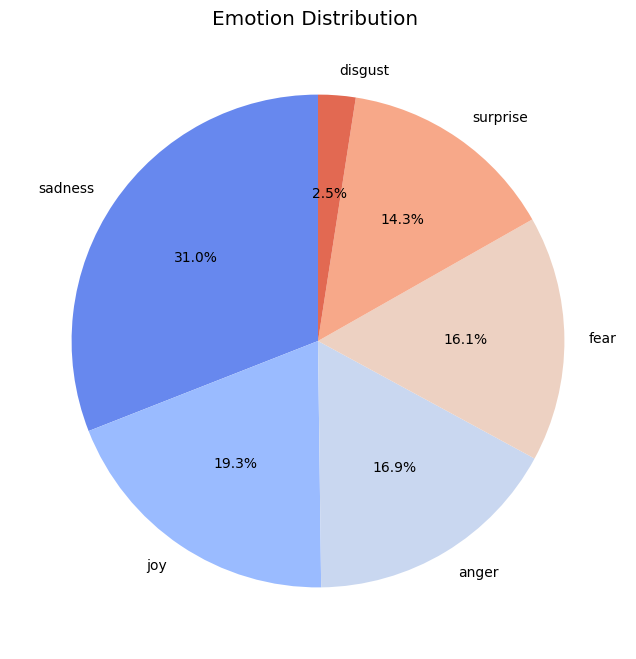

In [14]:
# Filter out 'neutral' emotion
filtered_df = df[df['emotion'] != 'neutral']

# Count the occurrences of each emotion (excluding neutral)
emotion_counts = filtered_df['emotion'].value_counts()

# Plot the distribution of emotions as a pie chart
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('coolwarm', len(emotion_counts)))
plt.title('Emotion Distribution ')
plt.show()
